# Module: Baseline Metrics

When assessing the quality of a segmentation, the first thing one usually looks at are summary metrics
such as the number of segmented cells, number of transcripts/genes per cell,
the percentage of unassigned transcripts, the transcript density, and a variety of morphological features.

<center>
 <img src='../_static/img/docs/baseline.png' width='90%' />
</center>

The `baseline` (`bl`) module contains several metrics that can help you to assess the quality of your segmentation.
The methods all return their corresponding values or dataframes, and also write them into the spatialdata object.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math

import matplotlib.pyplot as plt
import spatialdata as sd

import segtraq

sdata = sd.read_zarr("../../data/xenium_5K_data/proseg2.zarr")

# putting the spatialdata object into a SegTraQ constructor
# this has the advantage that we only need to set keywords like cell IDs or transcript IDs once
st = segtraq.SegTraQ(
    sdata,
    images_key=None,
    tables_area_key=None,
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


no parent found for <ome_zarr.reader.Label object at 0x7ffe485541a0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4857a990>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4857ad50>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe48598180>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe48598640>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe487b30b0>: None


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:162: UserWarning: Missing 4 cell IDs in shapes: [np.int64(11273), np.int64(10307), np.int64(10308), np.int64(6870)]... These cells are present in tables, but not in shapes. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1769: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcrip

To get a first impression of the quality of the data, we can check how many cells there are in the data.
We can also check how many transcripts were measured in total,
how many genes they map to, and how many transcripts were not assigned to a cell.

In [3]:
st.bl.num_cells()

17885

In [4]:
st.bl.num_transcripts()

2189801

In [5]:
st.bl.num_genes()

5095

In [6]:
st.bl.perc_unassigned_transcripts()

2.0661238167303786

Next, let's see how many transcripts were detected per cell.
We can do this using the `transcripts_per_cell()` method.

In [7]:
transcripts_per_cell = st.bl.transcripts_per_cell()
transcripts_per_cell.head()

,cell_id,transcript_count
0,3446,2345
1,1097,1777
2,2722,1458
3,2006,1407
4,2100,1314


We can plot the median and distribution of this to see how the number of transcripts differs across cells.

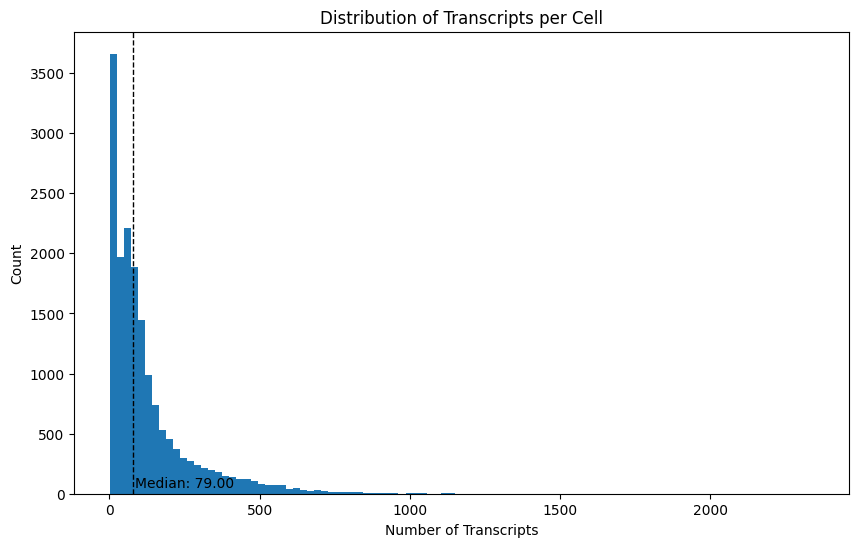

In [8]:
# plotting the number of transcripts per cell
plt.figure(figsize=(10, 6))
plt.hist(transcripts_per_cell["transcript_count"], bins=100)

# adding a line for the median
plt.axvline(
    transcripts_per_cell["transcript_count"].median(),
    color="black",
    linestyle="dashed",
    linewidth=1,
)
plt.text(
    transcripts_per_cell["transcript_count"].median() + 5,
    50,
    f"Median: {transcripts_per_cell['transcript_count'].median():.2f}",
    color="black",
)

# adding labels and title
plt.xlabel("Number of Transcripts")
plt.ylabel("Count")
plt.title("Distribution of Transcripts per Cell")
plt.show()

We can also do the same thing for the number of genes per cell,
since there are often multiple transcripts measured per gene.

In [9]:
genes_per_cell = st.bl.genes_per_cell()
genes_per_cell.head()

,cell_id,gene_count
0,1,389
1,2,45
2,3,5
3,4,120
4,5,41


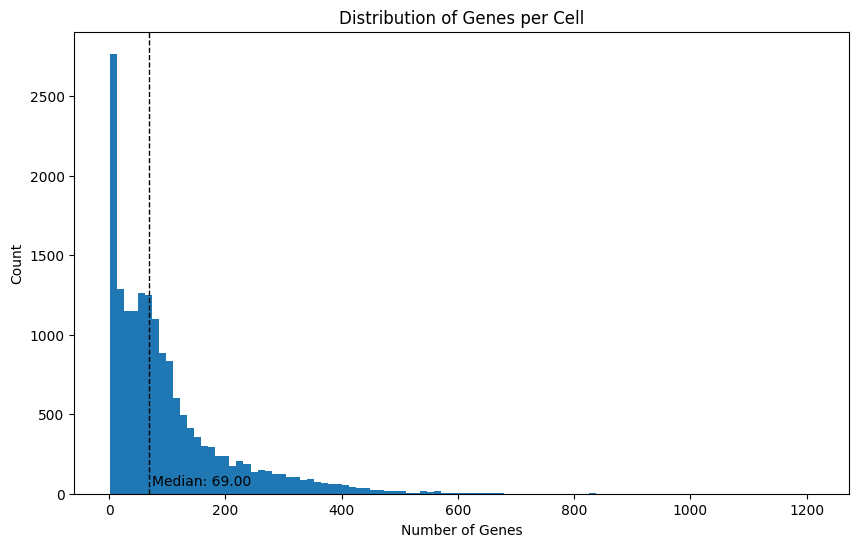

In [10]:
# plotting the number of genes per cell
plt.figure(figsize=(10, 6))
plt.hist(genes_per_cell["gene_count"], bins=100)

# adding a line for the median
plt.axvline(
    genes_per_cell["gene_count"].median(),
    color="black",
    linestyle="dashed",
    linewidth=1,
)
plt.text(
    genes_per_cell["gene_count"].median() + 5,
    50,
    f"Median: {genes_per_cell['gene_count'].median():.2f}",
    color="black",
)

# adding labels and title
plt.xlabel("Number of Genes")
plt.ylabel("Count")
plt.title("Distribution of Genes per Cell")
plt.show()

Next to the number of transcripts per cell, we can also investigate the transcript density,
which is computed as the number of transcripts divided by the cell area.
Note that the background does not appear in this data frame.

In [11]:
transcript_density = st.bl.transcript_density()
transcript_density.head()

,cell_id,transcript_density
0,1,2.391061
1,2,0.989691
2,3,0.171429
3,4,1.993355
4,5,0.508108


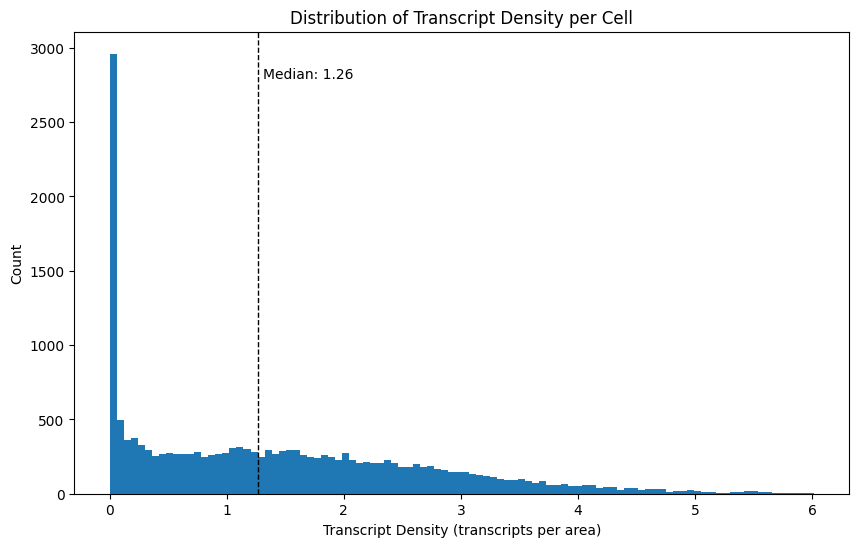

In [12]:
x = transcript_density["transcript_density"].dropna()

p99 = x.quantile(0.99)
x_clip = x[x <= p99]

plt.figure(figsize=(10, 6))
plt.hist(x_clip, bins=100)

# median from full distribution
med = x.median()

plt.axvline(med, color="black", linestyle="dashed", linewidth=1)
plt.text(
    med + 0.05,
    plt.ylim()[1] * 0.9,
    f"Median: {med:.2f}",
    color="black",
)

# adding labels and title
plt.xlabel("Transcript Density (transcripts per area)")
plt.ylabel("Count")
plt.title("Distribution of Transcript Density per Cell")
plt.show()

We can also compute the mean number of transcripts per detected gene per cell,
which is computed by averaging per-gene transcript counts across genes observed in each cell.
Note that only detected genes are considered and background transcripts are excluded.

In [13]:
mean_transcripts_per_gene_per_cell = st.bl.mean_transcripts_per_gene_per_cell()
mean_transcripts_per_gene_per_cell.head()

,cell_id,mean_transcripts_per_gene
0,1,1.375321
1,2,1.066667
2,3,1.200000
3,4,1.250000
4,5,1.146341


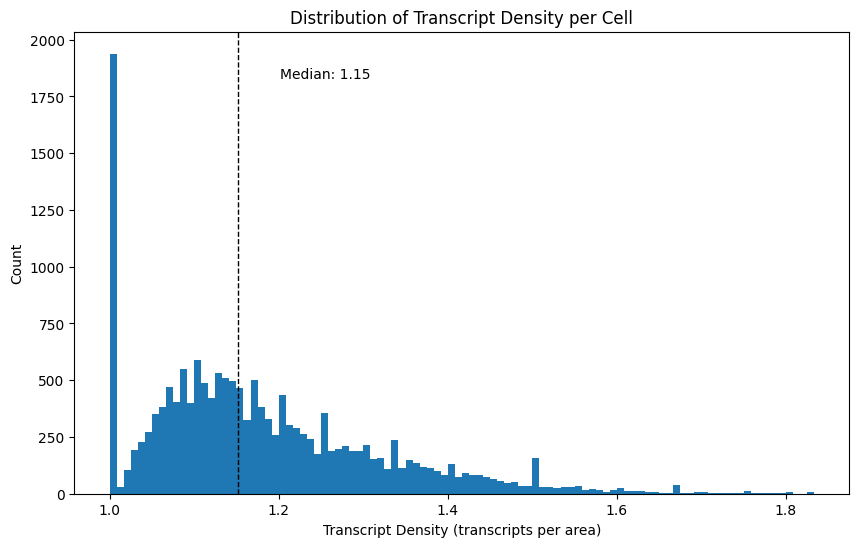

In [14]:
x = mean_transcripts_per_gene_per_cell["mean_transcripts_per_gene"].dropna()

p99 = x.quantile(0.99)
x_clip = x[x <= p99]

plt.figure(figsize=(10, 6))
plt.hist(x_clip, bins=100)

# median from full distribution
med = x.median()

plt.axvline(med, color="black", linestyle="dashed", linewidth=1)
plt.text(
    med + 0.05,
    plt.ylim()[1] * 0.9,
    f"Median: {med:.2f}",
    color="black",
)

# adding labels and title
plt.xlabel("Transcript Density (transcripts per area)")
plt.ylabel("Count")
plt.title("Distribution of Transcript Density per Cell")
plt.show()

Finally, let's look at some morphological features,
such as the cell area, circularity, elongation, etc.
We can get those with the function `morphological_features()`.
If you only want to compute certain features, you can select them with the
`features_to_compute` argument. This can drastically reduce the runtime,
as especially the features `elongation` and `eccentricity` can take a while to compute.

In [15]:
morphological_features = st.bl.morphological_features()
morphological_features.head()

,cell_id,num_polygons,cell_area,perimeter,circularity,solidity,convexity,elongation,eccentricity,compactness
0,1,3,223.75,77.291274,0.470665,0.874023,0.867660,2.153846,0.885685,26.699178
1,2,1,48.50,28.825554,0.733494,0.906542,0.955507,1.090909,0.399653,17.132217
2,3,1,35.00,27.756656,0.570878,0.853659,0.914635,1.368421,0.682625,22.012341
3,4,3,75.25,42.007644,0.535870,0.817935,0.865989,1.130435,0.466321,23.450394
4,5,1,92.50,44.342251,0.591175,0.864486,0.863819,1.119565,0.449652,21.256597


Let's plot all of the distributions in one plot using subplots.

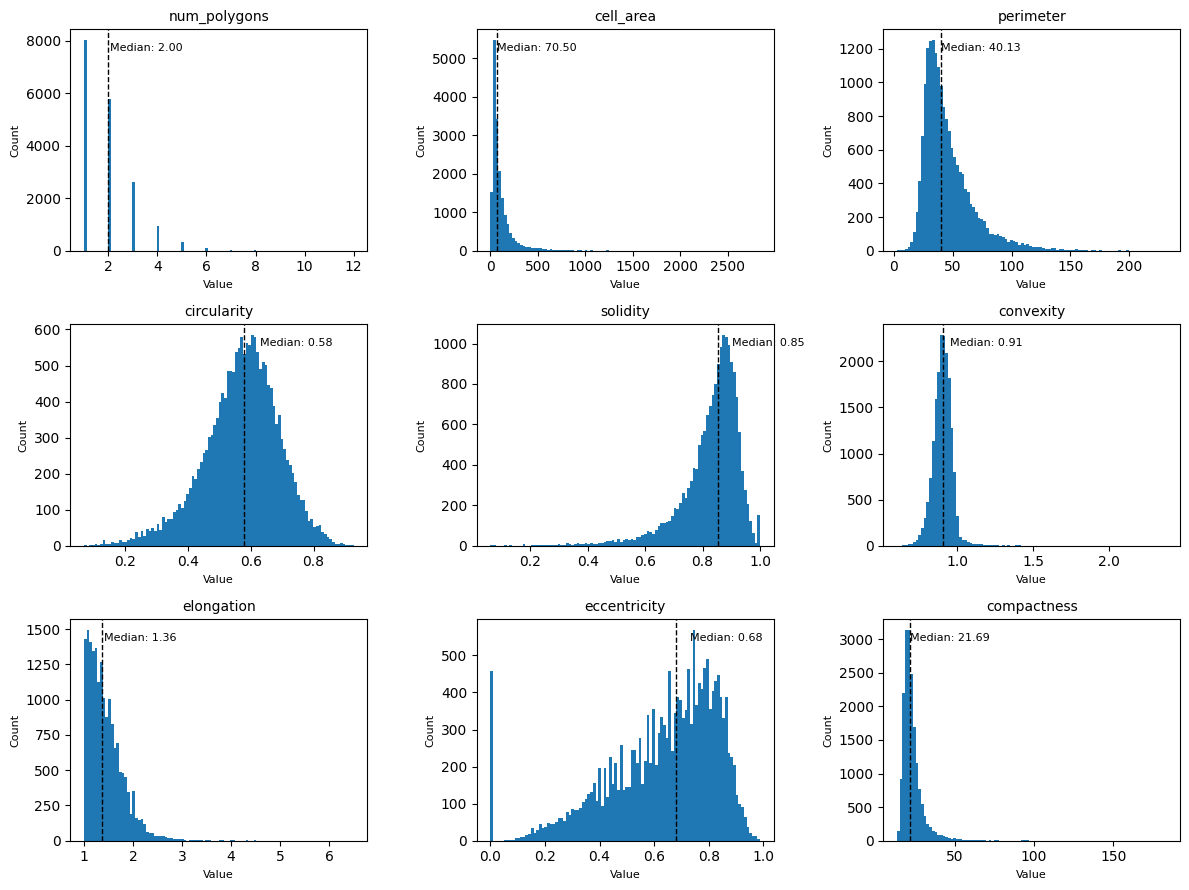

In [16]:
# exclude 'cell_id' from the features to plot
features = [f for f in morphological_features.columns if f != "cell_id"]

# define grid layout
num_features = len(features)
cols = 3
rows = math.ceil(num_features / cols)

# create subplots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    data = morphological_features[feature]

    ax.hist(data, bins=100)
    median_val = data.median()
    ax.axvline(median_val, color="black", linestyle="dashed", linewidth=1)
    ax.text(
        median_val + 0.05,
        ax.get_ylim()[1] * 0.9,
        f"Median: {median_val:.2f}",
        color="black",
        fontsize=8,
    )

    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("Value", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)

# hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

Instead of measures per cell, we can also compute some metrics per gene.
For example, we can see the percentage of how often a gene was not assigned to any cell.
This can help to detect potential biases in our segmentation.

In [17]:
perc_unassigned_transcripts_per_gene = st.bl.perc_unassigned_transcripts_per_gene()
perc_unassigned_transcripts_per_gene.sort_values(by="perc_unassigned", ascending=False).head()

,total,unassigned,perc_unassigned
feature_name,,,
HPV16-E7,1,1,100.000000
CIDEC,169,105,62.130178
GHR,118,69,58.474576
PLIN1,240,137,57.083333
SLC1A1,22,12,54.545455


In our example, most transcripts were assigned to a cell.
However, if you detected that a large number of transcripts were unassigned,
you could follow up with a gene set enrichment analysis (GSEA) to look for specific biases.

Finally, we can check the anndata object to verify that all of our metrics are stored in there.

In [18]:
sdata.tables["table"]

AnnData object with n_obs × n_vars = 17885 × 5095
    obs: 'cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'volume', 'label_id', 'region', 'gene_count', 'transcript_count', 'transcript_density', 'mean_transcripts_per_gene', 'num_polygons', 'cell_area', 'perimeter', 'circularity', 'solidity', 'convexity', 'elongation', 'eccentricity', 'compactness'
    var: 'total', 'unassigned', 'perc_unassigned'
    uns: 'spatialdata_attrs', 'num_cells', 'num_transcripts', 'num_genes', 'perc_unassigned_transcripts'
    layers: 'X_estimated'

Alternatively, all `bl` metrics can be computed in one run via `run_baseline`.

In [19]:
st.run_baseline()
sdata.tables["table"].obs.head()

,cell_id,centroid_x,centroid_y,centroid_z,volume,label_id,region,gene_count,mean_transcripts_per_gene,transcript_count,transcript_density,num_polygons,cell_area,perimeter,circularity,solidity,convexity,elongation,eccentricity,compactness
0,1,154.66340,1053.59360,-0.115346,1131.67400,1,cell_boundaries,389.0,1.375321,535.0,2.391061,3.0,223.75,77.291274,0.470665,0.874023,0.867660,2.153846,0.885685,26.699178
1,2,348.67285,287.59875,0.524985,256.04938,2,cell_boundaries,45.0,1.066667,48.0,0.989691,1.0,48.50,28.825554,0.733494,0.906542,0.955507,1.090909,0.399653,17.132217
2,3,720.20215,1218.87230,0.660745,148.57190,3,cell_boundaries,5.0,1.200000,6.0,0.171429,1.0,35.00,27.756656,0.570878,0.853659,0.914635,1.368421,0.682625,22.012341
3,4,877.44590,1707.41210,-0.980020,233.92108,4,cell_boundaries,120.0,1.250000,150.0,1.993355,3.0,75.25,42.007644,0.535870,0.817935,0.865989,1.130435,0.466321,23.450394
4,5,1253.77540,1426.49510,0.859675,327.17487,5,cell_boundaries,41.0,1.146341,47.0,0.508108,1.0,92.50,44.342251,0.591175,0.864486,0.863819,1.119565,0.449652,21.256597


In [20]:
sdata.tables["table"].var.head()

,total,unassigned,perc_unassigned
gene_symbol,,,
EEF1G,29662,568,1.914908
XBP1,24838,42,0.169096
TIMP3,18879,74,0.391970
RAB11FIP1,15609,24,0.153757
H3F3B,13492,368,2.727542


## Session Info

In [21]:
print(sd.__version__)  # spatialdata

0.8.0
